# Рубежный контроль №1

**ФИО:** Юрченко Кирилл Геннадьевич

**Группа:** ИУ5-64Б

**Вариант:** 23

**Задача:** Масштабирование и кодирование признаков

## Загрузка и подготовка данных

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

In [25]:
# Загружаем датасет
try:
    df = pd.read_csv('googleplaystore.csv')
    print(f"Датасет загружен: {df.shape[0]} приложений, {df.shape[1]} признаков")
except FileNotFoundError:
    print("Ошибка: файл googleplaystore.csv не найден")

Датасет загружен: 10841 приложений, 13 признаков


In [26]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [27]:
print("Информация о датасете:")
df.info()

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [28]:
print("Пропуски в данных:")
print(df.isnull().sum())

Пропуски в данных:
App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64


## Описание датасета

Датасет Google Play Store Apps содержит данные о приложениях: рейтинги, категории, тип (Free/Paid), количество установок и отзывов. Всего 10,841 записей и 13 признаков. Содержит пропуски в полях Rating, Type и других.

## Первичный анализ

In [29]:
print("Столбцы:")
print(df.columns.tolist())

Столбцы:
['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']


In [30]:
print("Описание числовых признаков:")
df.describe()

Описание числовых признаков:


,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [31]:
print("Описание категориальных признаков:")
df.describe(include='object')

Описание категориальных признаков:


,App,Category,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
count,10841,10841,10841,10841,10841,10840,10841,10840,10841,10841,10833,10838
unique,9660,34,6002,462,22,3,93,6,120,1378,2832,33
top,ROBLOX,FAMILY,0,Varies with device,"1,000,000+",Free,0,Everyone,Tools,"August 3, 2018",Varies with device,4.1 and up
freq,9,1972,596,1695,1579,10039,10040,8714,842,326,1459,2451


## Предобработка данных

In [32]:
data = df.copy()

# Обработка Rating
data['Rating'] = pd.to_numeric(data['Rating'], errors='coerce')
data = data[(data['Rating'] >= 0) & (data['Rating'] <= 5)]
data = data[data['Rating'].notna()]

print(f"Размер после очистки Rating: {len(data)}")

Размер после очистки Rating: 9366


In [33]:
# Обработка Reviews
data['Reviews'] = pd.to_numeric(data['Reviews'], errors='coerce')

# Обработка Installs
data['Installs_num'] = data['Installs'].str.replace(',', '', regex=False).str.replace('+', '', regex=False)
data['Installs_num'] = pd.to_numeric(data['Installs_num'], errors='coerce')

# Обработка Price
data['Price_num'] = data['Price'].str.replace('$', '', regex=False)
data['Price_num'] = pd.to_numeric(data['Price_num'], errors='coerce')

print("Преобразования завершены")

Преобразования завершены


In [34]:
# Удаление пропусков
print(f"До: {len(data)} строк")
data = data.dropna(subset=['Rating', 'Type'])
print(f"После: {len(data)} строк")

До: 9366 строк
После: 9366 строк


In [35]:
# Создание рабочего датафрейма
work_df = data[['Rating', 'Type', 'Category', 'Reviews', 'Installs_num', 'Price_num']].copy()

print(f"Рабочий датафрейм: {work_df.shape}")
work_df.head()

Рабочий датафрейм: (9366, 6)


,Rating,Type,Category,Reviews,Installs_num,Price_num
0,4.1,Free,ART_AND_DESIGN,159,10000,0.0
1,3.9,Free,ART_AND_DESIGN,967,500000,0.0
2,4.7,Free,ART_AND_DESIGN,87510,5000000,0.0
3,4.5,Free,ART_AND_DESIGN,215644,50000000,0.0
4,4.3,Free,ART_AND_DESIGN,967,100000,0.0


## Масштабирование числового признака

In [36]:
# StandardScaler
scaler_std = StandardScaler()
work_df['Rating_standard'] = scaler_std.fit_transform(work_df[['Rating']])

# MinMaxScaler
scaler_minmax = MinMaxScaler()
work_df['Rating_minmax'] = scaler_minmax.fit_transform(work_df[['Rating']])

print("Масштабирование выполнено")

Масштабирование выполнено


In [37]:
# Сравнение методов масштабирования
comparison = work_df[['Rating', 'Rating_standard', 'Rating_minmax']].head(15)
print("Сравнение методов:")
print(comparison)

print(f"\nОригинальный Rating: min={work_df['Rating'].min()}, max={work_df['Rating'].max()}")
print(f"StandardScaler: mean={work_df['Rating_standard'].mean():.4f}, std={work_df['Rating_standard'].std():.4f}")
print(f"MinMaxScaler: min={work_df['Rating_minmax'].min():.4f}, max={work_df['Rating_minmax'].max():.4f}")

Сравнение методов:
    Rating  Rating_standard  Rating_minmax
0      4.1        -0.178104          0.775
1      3.9        -0.566309          0.725
2      4.7         0.986512          0.925
3      4.5         0.598307          0.875
4      4.3         0.210102          0.825
5      4.4         0.404204          0.850
6      3.8        -0.760411          0.700
7      4.1        -0.178104          0.775
8      4.4         0.404204          0.850
9      4.7         0.986512          0.925
10     4.4         0.404204          0.850
11     4.4         0.404204          0.850
12     4.2         0.015999          0.800
13     4.6         0.792410          0.900
14     4.4         0.404204          0.850

Оригинальный Rating: min=1.0, max=5.0
StandardScaler: mean=-0.0000, std=1.0001
MinMaxScaler: min=0.0000, max=1.0000


### Результаты масштабирования

**StandardScaler** преобразует данные по формуле: (x - mean) / std. После применения получаем распределение с mean ≈ 0 и std ≈ 1. Используется в алгоритмах, чувствительных к масштабу: SVM, KNN, линейная регрессия.

**MinMaxScaler** приводит значения в диапазон [0, 1] по формуле: (x - min) / (max - min). Сохраняет форму распределения. Полезен когда нужен фиксированный диапазон.

Масштабирование необходимо, чтобы признаки с разными диапазонами не влияли на модель непропорционально.

## Label Encoding категориального признака

In [38]:
# Информация о Type
print("Уникальные типы:")
print(work_df['Type'].value_counts())

Уникальные типы:
Type
Free    8719
Paid     647
Name: count, dtype: int64


In [39]:
# Применяем Label Encoding
le = LabelEncoder()
work_df['Type_label'] = le.fit_transform(work_df['Type'])

print("Кодирование:")
for i, label in enumerate(le.classes_):
    count = (work_df['Type'] == label).sum()
    print(f"  {label} -> {i} ({count} приложений)")

Кодирование:
  Free -> 0 (8719 приложений)
  Paid -> 1 (647 приложений)


In [40]:
work_df[['Type', 'Type_label']].drop_duplicates().sort_values('Type_label')

,Type,Type_label
0,Free,0
234,Paid,1


### Анализ Label Encoding

Label Encoding преобразует категории в числовые метки: Free → 0, Paid → 1.

**Преимущества:** простой способ, не увеличивает размерность, хорошо работает для бинарных признаков.

**Недостатки:** для признаков с большим числом категорий может создать ложный порядок. Алгоритм может интерпретировать 0 < 1 < 2, хотя порядка нет. Для многокатегориальных признаков предпочтителен One Hot Encoding.

## One Hot Encoding категориального признака

In [41]:
# One Hot Encoding
type_ohe = pd.get_dummies(work_df['Type'], prefix='Type')
work_df = pd.concat([work_df, type_ohe], axis=1)

print(f"Созданы столбцы: {type_ohe.columns.tolist()}")

Созданы столбцы: ['Type_Free', 'Type_Paid']


In [42]:
# Сравнение методов кодирования
result = work_df[['Type', 'Type_label', 'Type_Free', 'Type_Paid']].head(8)
result['Type_Free'] = result['Type_Free'].astype(int)
result['Type_Paid'] = result['Type_Paid'].astype(int)

print("Сравнение методов кодирования:")
print(result)

Сравнение методов кодирования:
   Type  Type_label  Type_Free  Type_Paid
0  Free           0          1          0
1  Free           0          1          0
2  Free           0          1          0
3  Free           0          1          0
4  Free           0          1          0
5  Free           0          1          0
6  Free           0          1          0
7  Free           0          1          0


### Анализ One Hot Encoding

One Hot Encoding создает отдельный бинарный столбец для каждой категории:
- Type_Free: [1, 0, 1, 0, ...]
- Type_Paid: [0, 1, 0, 1, ...]

**Преимущества:** не создает искусственного порядка, работает корректно с любыми категориями, хорошо для линейных моделей.

**Недостатки:** увеличивает количество признаков, может привести к мультиколлинеарности, требует больше памяти.

**Вывод:** One Hot Encoding предпочтительнее, когда нет естественного порядка между категориями, особенно для линейных моделей.

## Анализ распределений - Violin Plot

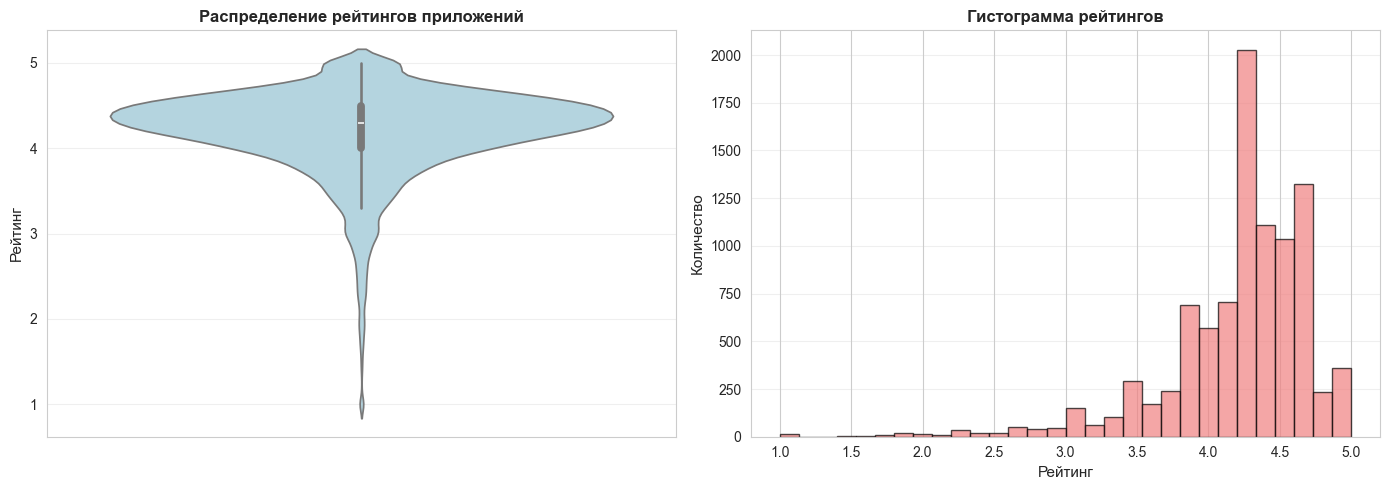

In [43]:
# Распределение Rating
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.violinplot(y=work_df['Rating'], ax=axes[0], color='lightblue', inner='box')
axes[0].set_title('Распределение рейтингов приложений', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Рейтинг', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

axes[1].hist(work_df['Rating'], bins=30, color='lightcoral', edgecolor='black', alpha=0.7)
axes[1].set_title('Гистограмма рейтингов', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Рейтинг', fontsize=11)
axes[1].set_ylabel('Количество', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

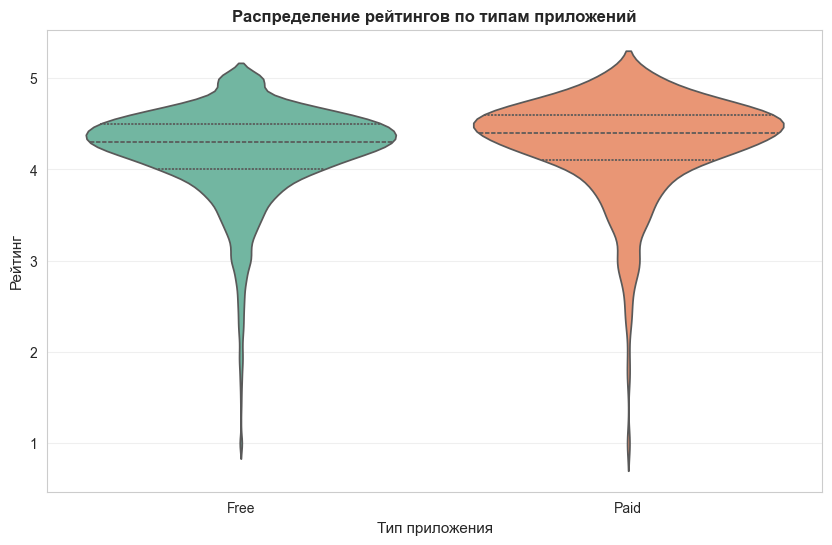

In [44]:
# Распределение Rating по типам
plt.figure(figsize=(10, 6))
sns.violinplot(data=work_df, x='Type', y='Rating', palette='Set2', inner='quartile')
plt.title('Распределение рейтингов по типам приложений', fontsize=12, fontweight='bold')
plt.xlabel('Тип приложения', fontsize=11)
plt.ylabel('Рейтинг', fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [45]:
# Статистика по типам
print("Статистика рейтингов по типам:")
print(work_df.groupby('Type')['Rating'].describe())

Статистика рейтингов по типам:
       count      mean       std  min  25%  50%  75%  max
Type                                                     
Free  8719.0  4.186203  0.512338  1.0  4.0  4.3  4.5  5.0
Paid   647.0  4.266615  0.547523  1.0  4.1  4.4  4.6  5.0


## Итоговые результаты

### Обработка данных

- Исходный датасет: 10,841 приложений
- После очистки: 9,366 приложений (удалено 1,475 строк с некорректными данными)
- Обработаны признаки Rating, Reviews, Installs, Price

### Масштабирование Rating

Применены два метода масштабирования:

**StandardScaler:** преобразует (x - mean) / std, получаем mean ≈ 0 и std ≈ 1. Применяется для SVM, KNN, линейных моделей.

**MinMaxScaler:** преобразует (x - min) / (max - min), приводит в [0, 1]. Полезен когда нужен фиксированный диапазон.

### Кодирование Type

**Label Encoding:** Free → 0, Paid → 1. Простой способ для бинарных признаков, но может создать ложный порядок для многокатегориальных.

**One Hot Encoding:** Type_Free и Type_Paid. Не создает порядка, предпочтителен для линейных моделей.

### Выводы

- Большинство приложений имеют рейтинг 4.0-4.5 звёзд
- Платные приложения немного лучше оценены (4.27 vs 4.19)
- One Hot Encoding предпочтительнее, когда нет естественного порядка между категориями
- Масштабирование критично для алгоритмов, чувствительных к масштабу